In [1]:
!pip install --upgrade google-cloud-bigquery
!pip install --upgrade google-auth


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.3/212.3 kB 11.5 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.38.0
    Uninstalling google-auth-2.38.0:
      Successfully uninstalled google-auth-2.38.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.39.0 which is incompatible.


In [2]:
from google.colab import auth
auth.authenticate_user()


In [3]:
from google.cloud import bigquery
import pandas as pd

#connecting Bquery to Python
client = bigquery.Client(project="bqproj-435911")


query = """
WITH cleaned_data AS (
  SELECT
    deviceid,
    'Carrefour' AS super_name,
    'Raanana' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) AS ts,
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time)) AS week_number
  FROM `bqproj-435911.fp_adid_super_db.carrefour_raanana`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Rami-Levi' AS super_name,
    'Haifa' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.rami_levy_haifa`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Shufersal-Nesher' AS super_name,
    'Nesher' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.shufersal_deal_nesher`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150
),


weekly_unique_devices AS (
  SELECT
    week_number,
    COUNT(DISTINCT deviceid) AS unique_devices
  FROM cleaned_data
  WHERE super_name='Carrefour'
  GROUP BY week_number
)

SELECT *
FROM weekly_unique_devices
ORDER BY week_number;


"""

#converting from SQL table to dataframe
df_carrefour= client.query(query).to_dataframe()


In [4]:
#check the data:
print(df_carrefour.head())
print(df_carrefour.info())


   week_number  unique_devices
0            0             206
1            1             231
2            2             221
3            3             155
4            4             172
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   week_number     53 non-null     Int64
 1   unique_devices  53 non-null     Int64
dtypes: Int64(2)
memory usage: 1.1 KB
None


In [8]:
import pandas as pd
import statsmodels.api as sm

#Casting all the variables to float
df_carrefour['week_number'] = df_carrefour['week_number'].astype(float)
df_carrefour['unique_devices'] = df_carrefour['unique_devices'].astype(float)

#Regression Variables
X = sm.add_constant(df_carrefour['week_number'])
y = df_carrefour['unique_devices']

# WE NEED AT LEAST 2 OBSERVATIONS TO CHECK THE EFFECT
if len(df_carrefour) < 2:
    print("Not Enough Data For the Regression")
else:
    model = sm.OLS(y, X).fit()

    # RESULTS
    print("slope", round(model.params['week_number'],3))
    print("intercept:", round(model.params['const'],3))
    print("p-value:", round(model.pvalues['week_number'],3))
    print("R-squared:", round(model.rsquared, 3))
    print("Number of observations:", int(model.nobs))


slope -1.649
intercept: 181.019
p-value: 0.006
R-squared: 0.139
Number of observations: 53


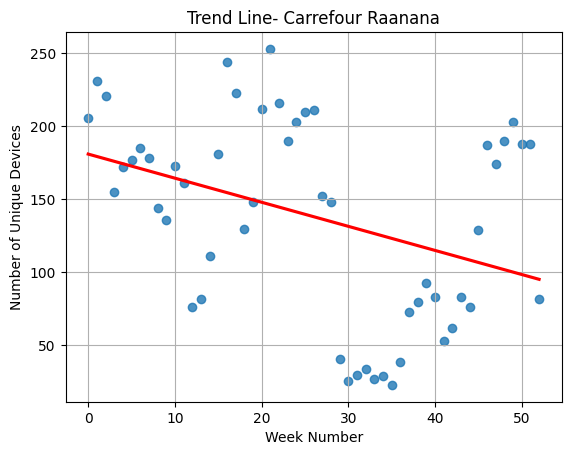

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

#SETTING THE VARIABLES
X = df_carrefour['week_number']
y = df_carrefour['unique_devices']

#PRODUCING THE REGRESSION TREND LINE
sns.regplot(x=X, y=y, ci=None, line_kws={"color": "red"})
plt.title("Trend Line- Carrefour Raanana")
plt.xlabel("Week Number")
plt.ylabel("Number of Unique Devices")
plt.grid(True)
plt.show()


In [10]:
from google.cloud import bigquery
import pandas as pd

#connecting Bquery to Python
client = bigquery.Client(project="bqproj-435911")


query = """
WITH cleaned_data AS (
  SELECT
    deviceid,
    'Carrefour' AS super_name,
    'Raanana' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) AS ts,
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time)) AS week_number
  FROM `bqproj-435911.fp_adid_super_db.carrefour_raanana`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Rami-Levi' AS super_name,
    'Haifa' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.rami_levy_haifa`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Shufersal-Nesher' AS super_name,
    'Nesher' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.shufersal_deal_nesher`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150
),


weekly_unique_devices AS (
  SELECT
    week_number,
    COUNT(DISTINCT deviceid) AS unique_devices
  FROM cleaned_data
  WHERE super_name='Shufersal-Nesher'
  GROUP BY week_number
)

SELECT *
FROM weekly_unique_devices
ORDER BY week_number;


"""

#converting from SQL table to dataframe
df_Shufersal_Nesher= client.query(query).to_dataframe()

In [11]:
print(df_Shufersal_Nesher.head())
print(df_Shufersal_Nesher.info())

   week_number  unique_devices
0            0             388
1            1             441
2            2             402
3            3             377
4            4             417
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   week_number     53 non-null     Int64
 1   unique_devices  53 non-null     Int64
dtypes: Int64(2)
memory usage: 1.1 KB
None


In [12]:
#Casting all the variables to float
df_Shufersal_Nesher['week_number'] = df_Shufersal_Nesher['week_number'].astype(float)
df_Shufersal_Nesher['unique_devices'] = df_Shufersal_Nesher['unique_devices'].astype(float)

#Regression Variables
X = sm.add_constant(df_Shufersal_Nesher['week_number'])
y = df_Shufersal_Nesher['unique_devices']

# WE NEED AT LEAST 2 OBSERVATIONS TO CHECK THE EFFECT
if len(df_Shufersal_Nesher) < 2:
    print("Not Enough Data For the Regression")
else:
    model = sm.OLS(y, X).fit()

    # RESULTS
    print("slope", round(model.params['week_number'],3))
    print("intercept:", round(model.params['const'],3))
    print("p-value:", round(model.pvalues['week_number'],3))
    print("R-squared:", round(model.rsquared, 3))
    print("Number of observations:", int(model.nobs))



slope 1.225
intercept: 398.27
p-value: 0.12
R-squared: 0.047
Number of observations: 53


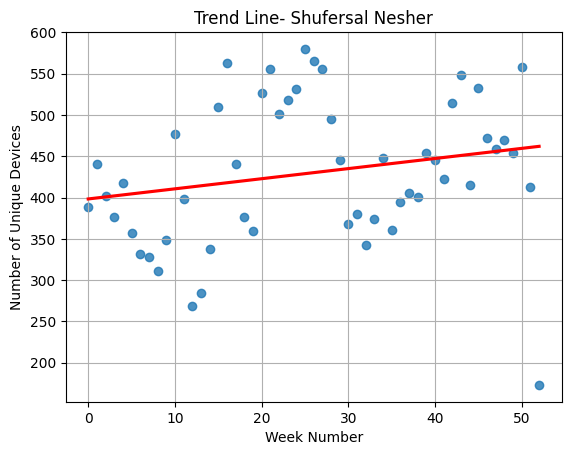

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

#SETTING THE VARIABLES
X = df_Shufersal_Nesher['week_number']
y = df_Shufersal_Nesher['unique_devices']

#PRODUCING THE REGRESSION TREND LINE
sns.regplot(x=X, y=y, ci=None, line_kws={"color": "red"})
plt.title("Trend Line- Shufersal Nesher")
plt.xlabel("Week Number")
plt.ylabel("Number of Unique Devices")
plt.grid(True)
plt.show()

In [ ]:
from google.cloud import bigquery
import pandas as pd

#connecting Bquery to Python
client = bigquery.Client(project="bqproj-435911")


query = """
WITH cleaned_data AS (
  SELECT
    deviceid,
    'Carrefour' AS super_name,
    'Raanana' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) AS ts,
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time)) AS week_number
  FROM `bqproj-435911.fp_adid_super_db.carrefour_raanana`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Rami-Levi' AS super_name,
    'Haifa' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.rami_levy_haifa`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Shufersal-Nesher' AS super_name,
    'Nesher' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.shufersal_deal_nesher`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150
),


weekly_unique_devices AS (
  SELECT
    week_number,
    COUNT(DISTINCT deviceid) AS unique_devices
  FROM cleaned_data
  WHERE super_name='Rami-Levi'
  GROUP BY week_number
)

SELECT *
FROM weekly_unique_devices
ORDER BY week_number;


"""

#converting from SQL table to dataframe
df_Rami_Levi= client.query(query).to_dataframe()

In [ ]:
#Casting all the variables to float
df_Rami_Levi['week_number'] = df_Rami_Levi['week_number'].astype(float)
df_Rami_Levi['unique_devices'] = df_Rami_Levi['unique_devices'].astype(float)

#Regression Variables
X = sm.add_constant(df_Rami_Levi['week_number'])
y = df_Rami_Levi['unique_devices']

# WE NEED AT LEAST 2 OBSERVATIONS TO CHECK THE EFFECT
if len(df_Rami_Levi) < 2:
    print("Not Enough Data For the Regression")
else:
    model = sm.OLS(y, X).fit()

    # RESULTS
    print("slope", model.params['week_number'])
    print("intercept:", model.params['const'])
    print("p-value:", model.pvalues['week_number'])
    print("R-squared:", model.rsquared)
    print("Number of observations:", int(model.nobs))


slope 0.2087566521528782
intercept: 60.59119496855352
p-value: 0.17663882049289487
R-squared: 0.0355036223020081
Number of observations: 53


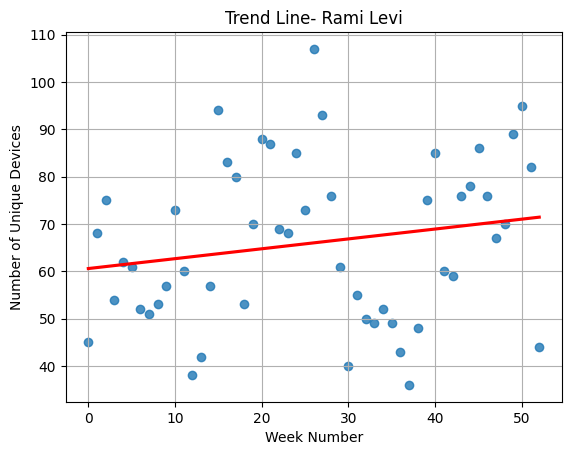

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#SETTING THE VARIABLES
X = df_Rami_Levi['week_number']
y = df_Rami_Levi['unique_devices']

#PRODUCING THE REGRESSION TREND LINE
sns.regplot(x=X, y=y, ci=None, line_kws={"color": "red"})
plt.title("Trend Line- Rami Levi")
plt.xlabel("Week Number")
plt.ylabel("Number of Unique Devices")
plt.grid(True)
plt.show()

In [15]:
#connecting Bquery to Python
client = bigquery.Client(project="bqproj-435911")


query = """

WITH cleaned_data AS (
  SELECT
    deviceid,
    'Carrefour-Raanana' AS super_name,
    'Raanana' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) AS ts,
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time)) AS week_number
  FROM `bqproj-435911.fp_adid_super_db.carrefour_raanana`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Rami-Levi-Haifa' AS super_name,
    'Haifa' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.rami_levy_haifa`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Shufersal-Nesher' AS super_name,
    'Nesher' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.shufersal_deal_nesher`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150
),
device_counts AS (
  SELECT
    super_name,
    city,
    week_number,
    COUNT(DISTINCT deviceid) AS unique_devices
  FROM cleaned_data
  GROUP BY super_name, city, week_number
),

super_areas AS (
  SELECT
    CONCAT(
    CASE
      WHEN p.Name LIKE '%שופרסל%' THEN 'Shufersal'
      WHEN p.Name LIKE '%רמי לוי%' THEN 'Rami-Levi'
      WHEN (p.Name LIKE '%קרפור%' OR p.Name LIKE '%Carrefour%') THEN 'Carrefour'
      ELSE 'Unknown'
    END,
    '-',
    CASE
      WHEN p.City LIKE '%חיפה%' THEN 'Haifa'
      WHEN p.City LIKE '%רעננה%' THEN 'Raanana'
      WHEN p.City LIKE '%נשר%' THEN 'Nesher'
      ELSE 'Unknown'
    END) AS super_name_city,
    CASE
      WHEN p.City LIKE '%חיפה%' THEN 'Haifa'
      WHEN p.City LIKE '%רעננה%' THEN 'Raanana'
      WHEN p.City LIKE '%נשר%' THEN 'Nesher'
      ELSE 'Unknown'
    END AS city,
    area
  from `bqproj-435911.fp_israel_super_db.israel_supermarkets_polygons` p
  join `bqproj-435911.fp_adid_super_db.israel_super_adid_scheme` s on p.centroid=s.centroid
  WHERE  (p.City LIKE '%חיפה%' or
       p.City LIKE '%רעננה%' or
       p.City LIKE '%נשר%' ) and(p.Name ='Carrefour' or p.Name LIKE '%שופרסל דיל%' or p.Name Like '%רמי לוי%')

)

SELECT
  d.week_number,
  d.unique_devices,
  a.area,
  SAFE_DIVIDE(a.area, d.unique_devices) AS area_per_device
FROM device_counts d
JOIN super_areas a
ON d.super_name = a.super_name_city
WHERE d.super_name='Carrefour-Raanana'
ORDER BY d.super_name, d.week_number;


"""

#converting from SQL table to dataframe
df_carrefour= client.query(query).to_dataframe()

In [16]:
#check the data:
print(df_carrefour.head())
print(df_carrefour.info())

   week_number  unique_devices         area  area_per_device
0            0             206  3247.003825        15.762154
1            1             231  3247.003825        14.056294
2            2             221  3247.003825        14.692325
3            3             155  3247.003825        20.948412
4            4             172  3247.003825        18.877929
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   week_number      53 non-null     Int64  
 1   unique_devices   53 non-null     Int64  
 2   area             53 non-null     float64
 3   area_per_device  53 non-null     float64
dtypes: Int64(2), float64(2)
memory usage: 1.9 KB
None


In [18]:
import statsmodels.api as sm

#Casting all the variables to float
df_carrefour['week_number'] = df_carrefour['week_number'].astype(float)
df_carrefour['area_per_device'] = df_carrefour['area_per_device'].astype(float)

#Regression Variables
X = sm.add_constant(df_carrefour['week_number'])
y = df_carrefour['area_per_device']

# WE NEED AT LEAST 2 OBSERVATIONS TO CHECK THE EFFECT
if len(df_carrefour) < 2:
    print("Not Enough Data For the Regression")
else:
    model = sm.OLS(y, X).fit()

    # RESULTS
    print("slope:", round(model.params['week_number'], 3))
    print("intercept:", round(model.params['const'], 2))
    print("p-value:", round(model.pvalues['week_number'], 4))
    print("R-squared:", round(model.rsquared, 3))
    print("Number of observations:", int(model.nobs))



slope: 0.618
intercept: 21.03
p-value: 0.036
R-squared: 0.083
Number of observations: 53


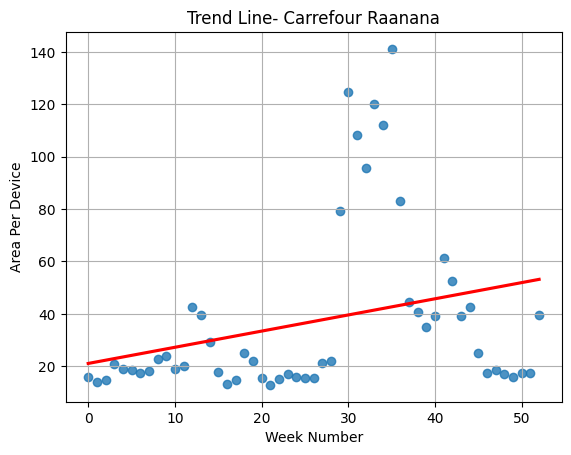

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

#SETTING THE VARIABLES
X = df_carrefour['week_number']
y = df_carrefour['area_per_device']

#PRODUCING THE REGRESSION TREND LINE
sns.regplot(x=X, y=y, ci=None, line_kws={"color": "red"})
plt.title("Trend Line- Carrefour Raanana")
plt.xlabel("Week Number")
plt.ylabel("Area Per Device")
plt.grid(True)
plt.show()

In [20]:
#connecting Bquery to Python
client = bigquery.Client(project="bqproj-435911")


query = """
WITH cleaned_data AS (
  SELECT
    deviceid,
    'Carrefour-Raanana' AS super_name,
    'Raanana' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) AS ts,
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time)) AS week_number
  FROM `bqproj-435911.fp_adid_super_db.carrefour_raanana`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Rami-Levi-Haifa' AS super_name,
    'Haifa' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.rami_levy_haifa`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Shufersal-Nesher' AS super_name,
    'Nesher' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.shufersal_deal_nesher`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150
),
device_counts AS (
  SELECT
    super_name,
    city,
    week_number,
    COUNT(DISTINCT deviceid) AS unique_devices
  FROM cleaned_data
  GROUP BY super_name, city, week_number
),

super_areas AS (
  SELECT
    CONCAT(
    CASE
      WHEN p.Name LIKE '%שופרסל%' THEN 'Shufersal'
      WHEN p.Name LIKE '%רמי לוי%' THEN 'Rami-Levi'
      WHEN (p.Name LIKE '%קרפור%' OR p.Name LIKE '%Carrefour%') THEN 'Carrefour'
      ELSE 'Unknown'
    END,
    '-',
    CASE
      WHEN p.City LIKE '%חיפה%' THEN 'Haifa'
      WHEN p.City LIKE '%רעננה%' THEN 'Raanana'
      WHEN p.City LIKE '%נשר%' THEN 'Nesher'
      ELSE 'Unknown'
    END) AS super_name_city,
    CASE
      WHEN p.City LIKE '%חיפה%' THEN 'Haifa'
      WHEN p.City LIKE '%רעננה%' THEN 'Raanana'
      WHEN p.City LIKE '%נשר%' THEN 'Nesher'
      ELSE 'Unknown'
    END AS city,
    area
  from `bqproj-435911.fp_israel_super_db.israel_supermarkets_polygons` p
  join `bqproj-435911.fp_adid_super_db.israel_super_adid_scheme` s on p.centroid=s.centroid
  WHERE  (p.City LIKE '%חיפה%' or
       p.City LIKE '%רעננה%' or
       p.City LIKE '%נשר%' ) and(p.Name ='Carrefour' or p.Name LIKE '%שופרסל דיל%' or p.Name Like '%רמי לוי%')

)

SELECT
  d.week_number,
  d.unique_devices,
  a.area,
  SAFE_DIVIDE(a.area, d.unique_devices) AS area_per_device
FROM device_counts d
JOIN super_areas a
ON d.super_name = a.super_name_city
WHERE d.super_name='Rami-Levi-Haifa'
ORDER BY d.super_name, d.week_number;


"""

#converting from SQL table to dataframe
df_Rami_Levi= client.query(query).to_dataframe()

In [ ]:
#check the data:
print(df_Rami_Levi.head())
print(df_Rami_Levi.info())

   week_number  unique_devices         area  area_per_device
0            0              45  2831.726941        62.927265
1            1              68  2831.726941        41.643043
2            2              75  2831.726941        37.756359
3            3              54  2831.726941        52.439388
4            4              62  2831.726941        45.673015
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   week_number      53 non-null     Int64  
 1   unique_devices   53 non-null     Int64  
 2   area             53 non-null     float64
 3   area_per_device  53 non-null     float64
dtypes: Int64(2), float64(2)
memory usage: 1.9 KB
None


In [ ]:
import statsmodels.api as sm

#Casting all the variables to float
df_Rami_Levi['week_number'] = df_Rami_Levi['week_number'].astype(float)
df_Rami_Levi['area_per_device'] = df_Rami_Levi['area_per_device'].astype(float)

#Regression Variables
X = sm.add_constant(df_Rami_Levi['week_number'])
y = df_Rami_Levi['area_per_device']

# WE NEED AT LEAST 2 OBSERVATIONS TO CHECK THE EFFECT
if len(df_Rami_Levi) < 2:
    print("Not Enough Data For the Regression")
else:
    model = sm.OLS(y, X).fit()

    # RESULTS
    print("slope", model.params['week_number'])
    print("intercept:", model.params['const'])
    print("p-value:", model.pvalues['week_number'])
    print("R-squared:", model.rsquared)
    print("Number of observations:", int(model.nobs))


slope -0.11669177657077624
intercept: 49.013044701304906
p-value: 0.3073926193219934
R-squared: 0.020417917036385957
Number of observations: 53


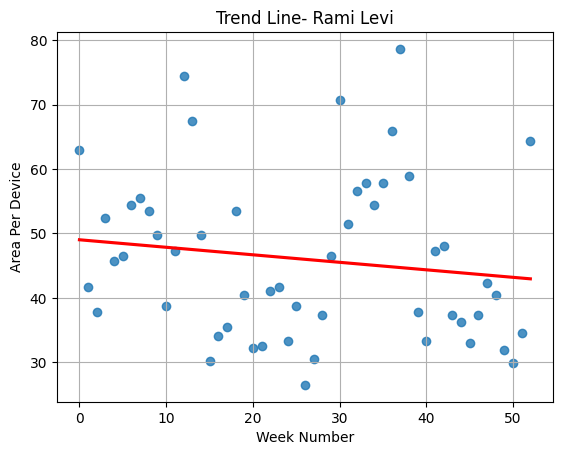

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#SETTING THE VARIABLES
X = df_Rami_Levi['week_number']
y = df_Rami_Levi['area_per_device']

#PRODUCING THE REGRESSION TREND LINE
sns.regplot(x=X, y=y, ci=None, line_kws={"color": "red"})
plt.title("Trend Line- Rami Levi")
plt.xlabel("Week Number")
plt.ylabel("Area Per Device")
plt.grid(True)
plt.show()

In [21]:
#connecting Bquery to Python
client = bigquery.Client(project="bqproj-435911")


query = """
WITH cleaned_data AS (
  SELECT
    deviceid,
    'Carrefour-Raanana' AS super_name,
    'Raanana' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) AS ts,
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time)) AS week_number
  FROM `bqproj-435911.fp_adid_super_db.carrefour_raanana`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Rami-Levi-Haifa' AS super_name,
    'Haifa' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.rami_levy_haifa`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150

  UNION ALL

  SELECT
    deviceid,
    'Shufersal-Nesher' AS super_name,
    'Nesher' AS city,
    PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time),
    EXTRACT(WEEK FROM PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time))
  FROM `bqproj-435911.fp_adid_super_db.shufersal_deal_nesher`
  WHERE deviceid IS NOT NULL AND eventtype IS NOT NULL AND accuracy IS NOT NULL
    AND PARSE_TIMESTAMP('%d/%m/%Y %H:%M:%S', israel_time) IS NOT NULL
    AND accuracy < 150
),
device_counts AS (
  SELECT
    super_name,
    city,
    week_number,
    COUNT(DISTINCT deviceid) AS unique_devices
  FROM cleaned_data
  GROUP BY super_name, city, week_number
),

super_areas AS (
  SELECT
    CONCAT(
    CASE
      WHEN p.Name LIKE '%שופרסל%' THEN 'Shufersal'
      WHEN p.Name LIKE '%רמי לוי%' THEN 'Rami-Levi'
      WHEN (p.Name LIKE '%קרפור%' OR p.Name LIKE '%Carrefour%') THEN 'Carrefour'
      ELSE 'Unknown'
    END,
    '-',
    CASE
      WHEN p.City LIKE '%חיפה%' THEN 'Haifa'
      WHEN p.City LIKE '%רעננה%' THEN 'Raanana'
      WHEN p.City LIKE '%נשר%' THEN 'Nesher'
      ELSE 'Unknown'
    END) AS super_name_city,
    CASE
      WHEN p.City LIKE '%חיפה%' THEN 'Haifa'
      WHEN p.City LIKE '%רעננה%' THEN 'Raanana'
      WHEN p.City LIKE '%נשר%' THEN 'Nesher'
      ELSE 'Unknown'
    END AS city,
    area
  from `bqproj-435911.fp_israel_super_db.israel_supermarkets_polygons` p
  join `bqproj-435911.fp_adid_super_db.israel_super_adid_scheme` s on p.centroid=s.centroid
  WHERE  (p.City LIKE '%חיפה%' or
       p.City LIKE '%רעננה%' or
       p.City LIKE '%נשר%' ) and(p.Name ='Carrefour' or p.Name LIKE '%שופרסל דיל%' or p.Name Like '%רמי לוי%')

)

SELECT
  d.week_number,
  d.unique_devices,
  a.area,
  SAFE_DIVIDE(a.area, d.unique_devices) AS area_per_device
FROM device_counts d
JOIN super_areas a
ON d.super_name = a.super_name_city
WHERE d.super_name='Shufersal-Nesher'
ORDER BY d.super_name, d.week_number;


"""

#converting from SQL table to dataframe
df_Shufersal_Nesher= client.query(query).to_dataframe()

In [22]:
print(df_Shufersal_Nesher.head())
print(df_Shufersal_Nesher.info())

   week_number  unique_devices         area  area_per_device
0            0             388  6352.414142        16.372201
1            1             441  6352.414142        14.404567
2            2             402  6352.414142        15.802025
3            3             377  6352.414142        16.849905
4            4             417  6352.414142        15.233607
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   week_number      53 non-null     Int64  
 1   unique_devices   53 non-null     Int64  
 2   area             53 non-null     float64
 3   area_per_device  53 non-null     float64
dtypes: Int64(2), float64(2)
memory usage: 1.9 KB
None


In [23]:
#Casting all the variables to float
df_Shufersal_Nesher['week_number'] = df_Shufersal_Nesher['week_number'].astype(float)
df_Shufersal_Nesher['area_per_device'] = df_Shufersal_Nesher['area_per_device'].astype(float)

#Regression Variables
X = sm.add_constant(df_Shufersal_Nesher['week_number'])
y = df_Shufersal_Nesher['area_per_device']

# WE NEED AT LEAST 2 OBSERVATIONS TO CHECK THE EFFECT
if len(df_Shufersal_Nesher) < 2:
    print("Not Enough Data For the Regression")
else:
    model = sm.OLS(y, X).fit()

    # RESULTS
    print("slope:", round(model.params['week_number'], 3))
    print("intercept:", round(model.params['const'], 2))
    print("p-value:", round(model.pvalues['week_number'], 4))
    print("R-squared:", round(model.rsquared, 3))
    print("Number of observations:", int(model.nobs))


slope: -0.026
intercept: 16.22
p-value: 0.4874
R-squared: 0.01
Number of observations: 53


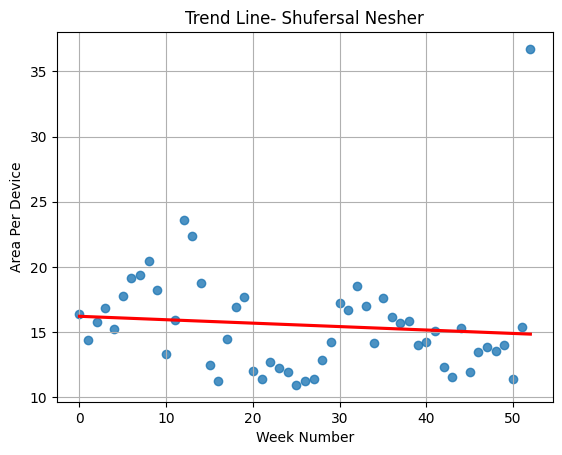

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

#SETTING THE VARIABLES
X = df_Shufersal_Nesher['week_number']
y = df_Shufersal_Nesher['area_per_device']

#PRODUCING THE REGRESSION TREND LINE
sns.regplot(x=X, y=y, ci=None, line_kws={"color": "red"})
plt.title("Trend Line- Shufersal Nesher")
plt.xlabel("Week Number")
plt.ylabel("Area Per Device")
plt.grid(True)
plt.show()